In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from mlxtend.plotting import plot_decision_regions


In [3]:
x,y = make_classification(n_samples = 1000,n_features = 2,n_informative = 2,n_redundant = 0,random_state= 45)

In [4]:
df = pd.DataFrame(x, columns=['Feature1', 'Feature2'])
df['Target'] = y

In [5]:
df.head(5)

,Feature1,Feature2,Target
0,1.170838,0.780634,1
1,-1.216037,-0.329699,0
2,-1.049912,-1.460877,0
3,-0.090035,-0.486183,0
4,0.669145,-1.178727,0


In [11]:
x_train,x_test,y_train,y_test =train_test_split(df[['Feature1', 'Feature2']], df['Target'],test_size = 0.2, random_state =42)

<Axes: >

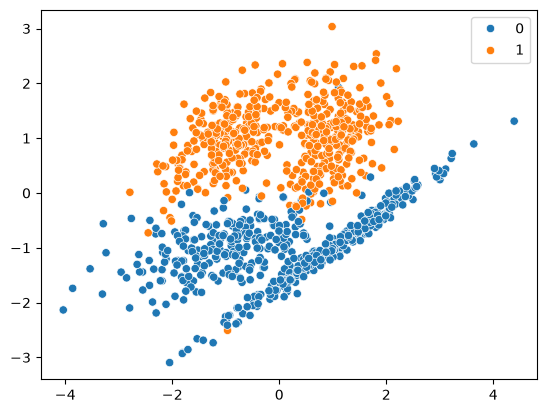

In [13]:
sns.scatterplot(x=x[:,0],y= x[:,1],hue = y)

In [24]:
class my_adaboost:
    def __init__(self):
        self.error = []
        self.models = []
        self.alphas = []
        self.n_estimators = 0
        self.weights = None
        self.history = []  
    
    def fit(self, X, y, n_estimators=10):
        if hasattr(X, 'values'):
            X = X.values
            
        if hasattr(y, 'values'):
            y = y.values
            
        self.n_estimators = n_estimators    
        self.weights = np.ones(len(X)) / len(X)  
        
        for i in range(n_estimators):
            
            # You need a loop for multiple estimators
            self.cal_lower_upper_range(self.weights)
            
            df = pd.DataFrame({
            'lower_range': self.lower_range,
            'upper_range': self.upper_range})

            indices = self.create_dt(df)

            X_sample = X[indices]
            y_sample = y[indices]


            DS1 = DecisionTreeClassifier(max_depth=1,)
            DS1.fit(X_sample, y_sample, sample_weight=self.weights)  
            
            plot_tree(DS1)
          
            plt.figure(figsize=(10, 8))
            plot_decision_regions(X,y,clf=DS1,legend=2)
            plt.title(f'AdaBoost Decision Boundary on Test Data')
            plt.xlabel('Feature 1')
            plt.ylabel('Feature 2')
            plt.show()
                
            y_pred = DS1.predict(X)  
            
            error = self.calculate_error(y, y_pred, self.weights)
            alpha = self.calculate_alpha(error)
            
            # Save weights BEFORE updating
            old_weights = self.weights.copy()
            
            # Update weights
            new_weights = self.update_weight(y, y_pred, alpha)

            
           
            
            self.models.append(DS1)
            self.alphas.append(alpha)
            self.error.append(error)
            
            self.history.append({
            'Estimator': i + 1,
            'Error': error,
            'Alpha': alpha,
            'Weights_Before': old_weights.copy(),
            'Weights_After': new_weights.copy(),
            'Predictions': y_pred.copy()
        })
                    
            summary_df = pd.DataFrame([
        {
            'Estimator': h['Estimator'],
            'Error': h['Error'],
            'Alpha': h['Alpha']
        }
            for h in self.history
    ])

        return summary_df
           
  
    
    def calculate_error(self, y, y_pred, weights):
        wrong = y != y_pred
        error = weights[wrong].sum()
        return error

    def calculate_alpha(self, error):
        # Add epsilon to avoid division by zero
        error = max(min(error, 1 - 1e-10), 1e-10)
        alpha = 0.5 * np.log((1 - error) / (error))
        return alpha
        
    def update_weight(self, y, y_pred, alpha):
        wrong = (y != y_pred)
        correct = ~wrong
        
        # Increase weights for wrong predictions, decrease for correct ones
        self.weights[wrong] *= np.exp(alpha)
        self.weights[correct] *= np.exp(-alpha)
        self.weights = self.weights / self.weights.sum()
        return self.weights
        
    def cal_lower_upper_range(self,weights):
        self.upper_range = np.cumsum(weights)
        self.lower_range = np.insert(self.upper_range[:-1], 0, 0)

    def create_dt(self,df):
            indices = []
            for i in range(df.shape[0]):
                a = np.random.random()
                for index, row in df.iterrows():
                    if row['lower_range'] <= a < row['upper_range']:
                        indices.append(index)
                        break
            return indices

    def predict(self,X):

        final_prediction = np.zeros(len(X))
        for model,alpha in zip(self.models,self.alphas):
            
            prediction = model.predict(X)
            
            final_prediction += alpha * prediction
            
        return np.sign(final_prediction)




        

In [26]:
Adb = my_adaboost()

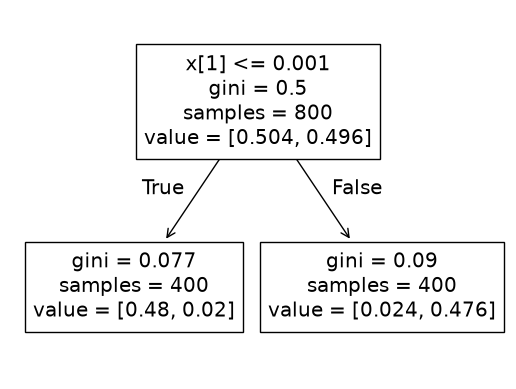

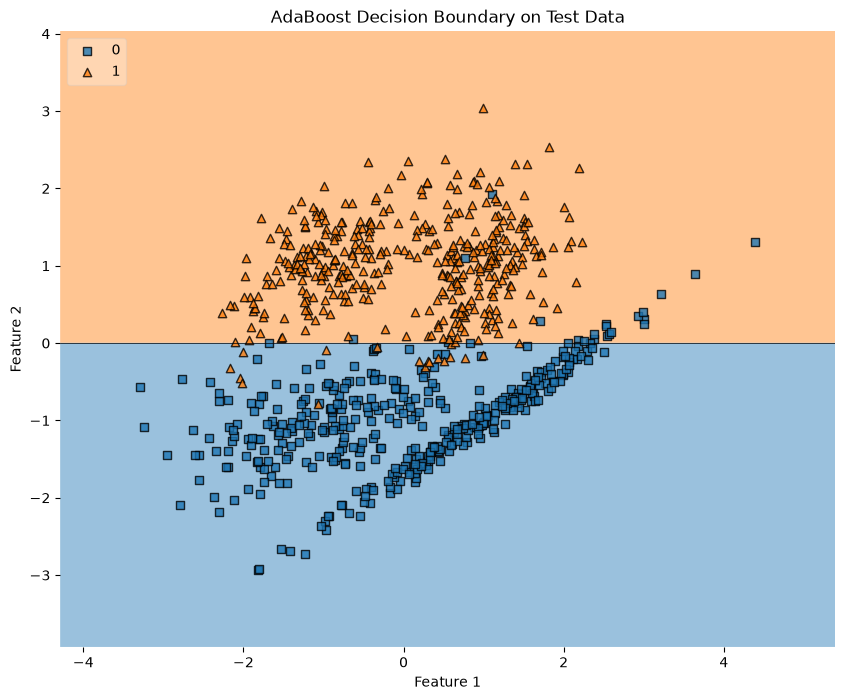

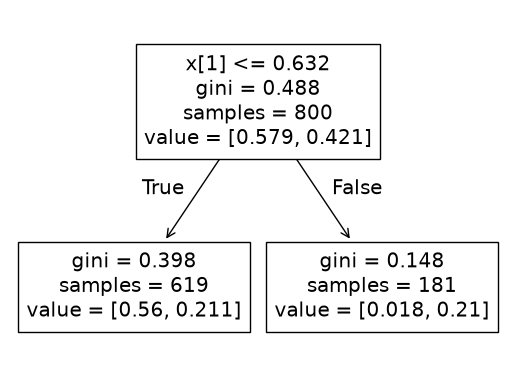

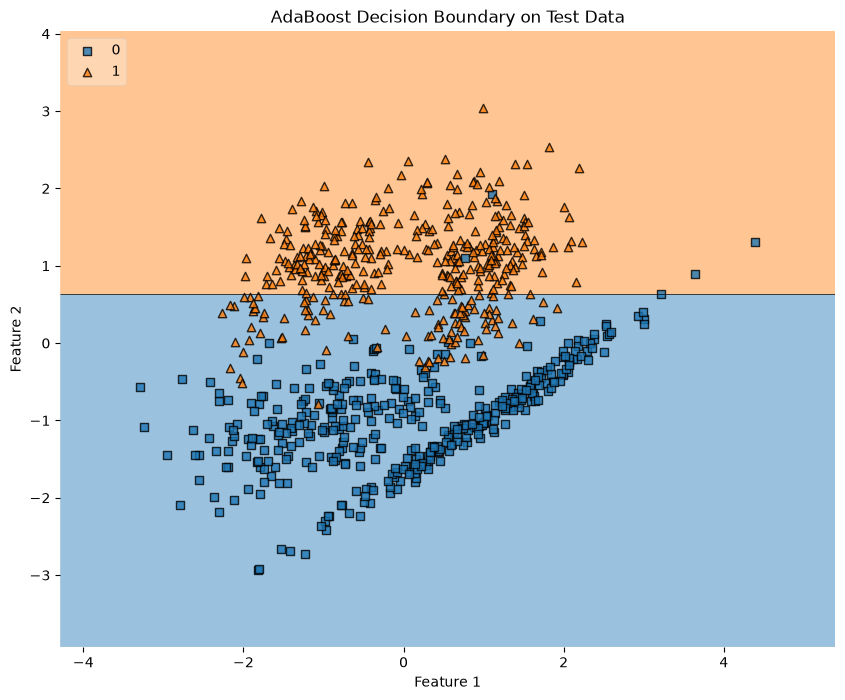

,Estimator,Error,Alpha
0,1,0.048750,1.485536
1,2,0.325735,0.363769


In [28]:
 Adb.fit(x_train,y_train,2)


In [29]:
pred = Adb.predict(x_test)

C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [36]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
y_pred = Adb.predict(x_test)

accuracy_score(y_test, y_pred)

C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
C:\Users\Umashree.K.dandin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


0.94

In [50]:
ADB = AdaBoostClassifier(
    n_estimators = 2,
    random_state = 42
)

In [52]:
ADB.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](2,)","[0.05,0.26]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](2,)","[3. ,1.05]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419)]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](2,)","[0.26,0.74]"


In [56]:
y_pred1 = ADB.predict(x_test)
accuracy_score1 = accuracy_score(y_test,y_pred1)
print(accuracy_score1)

0.94
